# Homework 5: Numerical Solutions to Differential Equations

## Out: 12/1/25
## Due: 12/12/25 at 3:30 pm
## 110 points total

## 1. Explicit Rabbits (25 points total)

Consider a simple ecosystem of rabbits that has an infinite food
supply and foxes that prey upon rabbits for their food.  A
mathematical model for this system consists of the following
differential equations:
\begin{eqnarray*}   
{{dr}\over{dt}} = 2 r - \alpha r f, \qquad r(0) = r_{0}, \\
{{df}\over{dt}} = -f + \alpha r f, \qquad f(0) = f_{0},
\end{eqnarray*}
where $t$ is time, $r$ is the number of rabbits, $f$ is the number of
foxes, and $\alpha$ is a positive constant that represents interaction between the species.  When $\alpha$ is zero,
the two populations do not interact, the rabbits do what rabbits
do best, and the foxes die of starvation.  This system has been
studied for various values of $\alpha$ and initial conditions.  For
the purposes of this problem, fix the value of $\alpha$ to be 0.01.
To answer the questions in parts a) and b) below, use a third order RK method (use a built in function) and the Leapfrog method (write your own code for this) to solve the differential
equations.  Use  the explicit Euler scheme  to start the integrations for the leapfrog method.  Compare
the results between your 2 solutions.  

**Hint**: The leapfrog method is defined as
$y_{n+1}=y_{n-1}+2hf(t_n,y_n)$ (Page 48 of textbook)

**Hint**: For the third order RK method, you should use the solve_ivp() function in Python with the "RK23" method.

### 1.1 Solution (10)

Plot the solution with $r_{0} = 300$ and $f_{0} = 150$.  You
should observe that the behavior of the system is periodic with a
period very close to five time units.  Plot the solution in the $(f,
r)$ plane (see https://scipy-cookbook.readthedocs.io/items/LoktaVolterraTutorial.html for an example).  If the time step is too large for the leapfrog method, what happens to the
periodicity of the solution? (10 points) (4 plots)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -----------------------------
# Parameters and ODE system
# -----------------------------
alpha = 0.01
r0, f0 = 300.0, 150.0           # initial conditions
y0 = [r0, f0]

def rabbits_foxes(t, y):
    """
    Lotka–Volterra-type system:
        dr/dt = 2 r - alpha r f
        df/dt = -f + alpha r f
    """
    r, f = y
    drdt = 2.0 * r - alpha * r * f
    dfdt = -1.0 * f + alpha * r * f
    return [drdt, dfdt]

# -----------------------------
# Reference solution with solve_ivp (RK23)
# -----------------------------
t0, t_end_rk = 0.0, 30.0
t_eval = np.linspace(t0, t_end_rk, 3001)   # ~0.01 time step for output

sol_rk = solve_ivp(
    rabbits_foxes,
    (t0, t_end_rk),
    y0,
    t_eval=t_eval,
    method="RK23"
)

t_rk = sol_rk.t
r_rk = sol_rk.y[0]
f_rk = sol_rk.y[1]

# -----------------------------
# Leapfrog integrator
# -----------------------------
def leapfrog(f, t0, y0, h, n_steps):
    """
    Leapfrog integrator for y' = f(t, y).
    """
    y0 = np.asarray(y0, float)
    m = y0.size

    t = np.zeros(n_steps + 1)
    y = np.zeros((n_steps + 1, m))

    # initial condition
    t[0] = t0
    y[0] = y0

    # first step: simple Euler to start leapfrog
    t[1] = t[0] + h
    y[1] = y[0] + h * np.asarray(f(t[0], y[0]), float)

    # main leapfrog loop
    for n in range(1, n_steps):
        t[n+1] = t[n] + h
        y[n+1] = y[n-1] + 2.0 * h * np.asarray(f(t[n], y[n]), float)

    return t, y

# -----------------------------
# Leapfrog with "good" time step
# -----------------------------
t_end_small = 10.0        # a couple of periods, stays well behaved
h_small = 0.01
N_small = int((t_end_small - t0) / h_small)

t_lf_small, y_lf_small = leapfrog(rabbits_foxes, t0, y0, h_small, N_small)
r_lf_small = y_lf_small[:, 0]
f_lf_small = y_lf_small[:, 1]

# -----------------------------
# Leapfrog with "too large" time step
# -----------------------------
t_end_large = 5.0         # one period is enough to see it go bad
h_large = 0.2             # intentionally too large
N_large = int((t_end_large - t0) / h_large)

t_lf_large, y_lf_large = leapfrog(rabbits_foxes, t0, y0, h_large, N_large)
r_lf_large = y_lf_large[:, 0]
f_lf_large = y_lf_large[:, 1]

# -----------------------------
# Plot 1: r(t) and f(t) from RK23
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(t_rk, r_rk, label="rabbits r(t)")
plt.plot(t_rk, f_rk, label="foxes f(t)")
plt.xlabel("time t")
plt.ylabel("population")
plt.title("Rabbits and foxes vs time (RK23)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Plot 2: Phase plane (f, r) from RK23
# -----------------------------
plt.figure(figsize=(6,5))
plt.plot(f_rk, r_rk)
plt.xlabel("foxes f(t)")
plt.ylabel("rabbits r(t)")
plt.title("Phase plane (f, r) – RK23")
plt.grid(True)
plt.show()

# -----------------------------
# Plot 3: Phase plane, RK23 vs leapfrog (small h)
# -----------------------------
# use only the part of RK solution up to t_end_small
mask_small = t_rk <= t_end_small

plt.figure(figsize=(6,5))
plt.plot(f_rk[mask_small], r_rk[mask_small], label="RK23")
plt.plot(f_lf_small, r_lf_small, "--", label=f"Leapfrog, h={h_small}")
plt.xlabel("foxes f(t)")
plt.ylabel("rabbits r(t)")
plt.title("Phase plane: small step leapfrog vs RK23")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot 4: Phase plane, RK23 vs leapfrog (large h)
# -----------------------------
mask_large = t_rk <= t_end_large

plt.figure(figsize=(6,5))
plt.plot(f_rk[mask_large], r_rk[mask_large], label="RK23")
plt.plot(f_lf_large, r_lf_large, "--", label=f"Leapfrog, h={h_large}")
plt.xlabel("foxes f(t)")
plt.ylabel("rabbits r(t)")
plt.title("Phase plane: large step leapfrog vs RK23")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Text answer for the question
# -----------------------------
print("Observation: with a too-large time step (h = 0.2),")
print("the leapfrog solution is no longer nicely periodic –")
print("the orbit in the (f, r) plane distorts and its amplitude grows,")
print("so the apparent period and shape of the cycle are wrong.")


### 1.2 Changing Initial Conditions (10)

Compute the solution with $r_{0} = 15$ and $f_{0} = 22$.  What
happens to the rabbit population?  Solve over several periods. (10 points) (2 plots)

### 1.3 Stability (5)

What is the maximum timestep you can use to obtain reasonable accuracy with the leapfrog method? (5 points)

## 2. Chemical Kinetics and Stiff Systems (25 points total)

$$\require{mhchem}$$  
The following equations model a chemical oscillator, a chemical
reaction which takes place in such a way that the concentrations of
the three chemical species vary periodically in time

\begin{eqnarray*}
y'_{1} & = & s\left(y_{2} - y_{1}y_{2} + y_{1} - qy_{1}^{2}\right), \\
y'_{2} & = & {{1}\over{s}}\left(y_{3} - y_{2} - y_{1}y_{2}\right), \\
y'_{3} & = & w\left(y_{1} - y_{3}\right), \\
\end{eqnarray*}
where for the colorful autocatalytic reaction, dubbed the ``Oregonator'' 
reaction, between $\ce{HBrO_{2}}$, $\ce{Br^{-}}$, and $\ce{Ce(IV)}$
\begin{eqnarray*}
s = 77.27, \qquad w = 0.1610, \qquad q = 8.375 \times 10^{-6}.
\end{eqnarray*}
The initial data are 
\begin{eqnarray*}
y_{1}(0) = 4.0, \qquad y_{2}(0) = 1.1, \qquad y_{3}(0) = 4.0.
\end{eqnarray*}
In this model $y_{1}$ is the concentration of bromous acid, $y_{2}$ is
the concentration of bromide ion, and $y_{3}$ is the concentration of
cerium IV.  By looking at the reaction rate constants, we expect to
see three disparate time scales in the solution.  If the output points
are too far apart, we can expect to lose some features of the
solution of this problem.

The objective is to find $y_{1}$, $y_{2}$, and $y_{3}$ as functions of
time for $0 \leq t \leq 620$.  

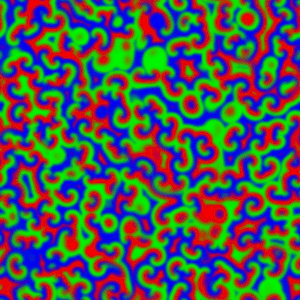

In [10]:
from IPython.display import Image
Image('The_Belousov-Zhabotinsky_Reaction.gif')

### 2.1 (10)

Use the stiff ODE solver (Radau method in solve_ivp) to solve the system of equations. Plot the concentrations as a function of time up to $t=620$. (10 points) (1 plot)

### 2.2 (10)

Use an explicit method such as fifth order Runge-Kutta 
with a constant time step.  Integrate to a time of 100 and print out the CPU time.   How much additional time would
it take to reach the final destination at $t = 620$? (10 points) (1 plot)

### 2.2 (5)

Discuss your results in a), and b) in particular the
CPU time required in each case to achieve similar accuracy.   (5 points) 

## 3. Heat and Mass Transport in a Catalyst Pellet (35 points)

 The following equations describe a non-isothermal first order reaction occuring on a flat plate catalyst pellet:
 
 $\frac{d^2\psi}{d\chi^2}=\phi^2\psi\exp\left[-\gamma\left(\frac{1}{\Gamma}-1\right)\right]$
 
  $\frac{d^2\Gamma}{d\chi^2}=-\beta\phi^2\psi\exp\left[-\gamma\left(\frac{1}{\Gamma}-1\right)\right]$
  
  with boundary conditions ($0\leq\chi\leq1$):
  
  $\left.\frac{d\psi}{d\chi}\right|_{\chi=0}=\left.\frac{d\Gamma}{d\chi}\right|_{\chi=0}=0$
  
  and
  $\left.\frac{d\psi}{d\chi}\right|_{\chi=1}=Bi_m(1-\psi(1))$
  
  $\left.\frac{d\Gamma}{d\chi}\right|_{\chi=1}=Bi_h(1-\Gamma(1))$
  
Here, the constants are the Thiele modulus ($\phi$), the heat and mass Biot numbers ($Bi_h,\ Bi_m$), $\gamma$ (related to the activation energy), and $\beta$ (related to the enthalpy of reaction). The terms $\psi$ and $\Gamma$ are the dimensionless concentration and temperature, respectively, and $\chi$ is the dimensionless length. For more discussion on this problem see the undergraduate reaction engineering textbook by Davis and Davis (https://authors.library.caltech.edu/records/arr0q-97509).

### 3a) Mass Transport Part I (10 points)

For the isothermal case ($\Gamma=1,\ \frac{d\Gamma}{d\chi}=0$) determine the analytical solution to the second order ODE (there is only one ODE now, you can ignore the differential equation for $\Gamma$) for the dimensionless concentration.

### 3b) Mass Transport Part 2 (25 points)

Still using the isothermal case, numerically solve the boundary value problem using the following values for the constants:

$\gamma=1,\ \beta=0.5,\phi=0.5, Bi_m=10,\ Bi_h=1$ Note that you do not need to use $Bi_h$ yet.

Make a plot of $\psi$ versus $\chi$ comparing your analytical solution (solid lines) to your numerical solution (dashed lines) using the same parameter values.

## 4. Partial Differential Equations (25 points total)

The following equation and conditions describe a single component transient plug flow reactor.  Solve for C(V,t) for a reactor of with a total volume of 25 cm$^3$.  Plot the concentration profile along the length of the reactor at intervals of 1s. (1 plot)

\begin{equation}\frac{\partial C}{\partial t}=-\nu\frac{\partial C}{\partial V}-kC^2\end{equation}

$C(0,t)=2\ \text{mol}\ \text{cm}^{-3},\ C(x,0)=0,\ \nu=2\ \text{cm}^3/s, k=1\ \text{mol}^{-1}s^{-1}$